In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, LeaveOneOut, cross_val_predict, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
import warnings

### 1. 엑셀 데이터 정보 확인

In [2]:
DATA_PATH = r'c:\Users\user\Desktop\김현호\1. 연구(kims )\1. 3DP\data\데이터베이스_소재DB.xlsx'

df = pd.read_excel(
    DATA_PATH,
    sheet_name='OM_단면',
    header=11,
    skiprows=[12],
    engine='openpyxl'
)

print('컬럼 목록:')
for i, col in enumerate(df.columns):
    print(f'  [{i}] {col!r}')
print(f'\n행 수: {len(df)}')
df.head()

컬럼 목록:
  [0] 'Unnamed: 0'
  [1] '항목'
  [2] 'Unnamed: 2'
  [3] '층 두께'
  [4] '레이저 파워'
  [5] '스캔 속도'
  [6] '에너지 밀도'
  [7] '기공률'
  [8] '평균 기공 크기'
  [9] '최대 기공 크기'
  [10] '기공크기 표준편차'
  [11] '단면 이미지1'
  [12] '단면 이미지2'
  [13] '단면 이미지3'
  [14] 'Unnamed: 14'
  [15] 'Unnamed: 15'
  [16] 'Unnamed: 16'
  [17] 'Unnamed: 17'
  [18] 'Unnamed: 18'
  [19] 'Unnamed: 19'
  [20] 'Unnamed: 20'
  [21] 'Unnamed: 21'
  [22] 'Unnamed: 22'
  [23] 'Unnamed: 23'
  [24] 'Unnamed: 24'
  [25] 'Unnamed: 25'
  [26] 'Unnamed: 26'
  [27] 'Unnamed: 27'
  [28] 'Unnamed: 28'
  [29] 'Unnamed: 29'
  [30] 'Unnamed: 30'
  [31] 'Unnamed: 31'

행 수: 180


,Unnamed: 0,항목,Unnamed: 2,층 두께,레이저 파워,스캔 속도,에너지 밀도,기공률,평균 기공 크기,최대 기공 크기,...,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,1,TIT1P1SS1,30,80,722,19.712872,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,2,TIT1P1SS2,30,80,1444,9.856436,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,3,TIT1P1SS3,30,80,2166,6.570957,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,4,TIT1P1SS4,30,80,2889,4.926512,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,5,TIT1P1SS5,30,80,3611,3.941483,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2. 데이터 전처리

유효 데이터 수: 102행
기공률 범위: 51.185 ~ 99.999
기공률 평균/표준편차: 93.837 / 11.263
Train: 81, Test: 21


In [ ]:
# ── 데이터 준비: 4개 공정 피처 → 기공률 ──
FEATURE_COLS4 = ['층 두께', '레이저 파워', '스캔 속도', '에너지 밀도']
TARGET_COL    = '기공률'

data4 = df[FEATURE_COLS4 + [TARGET_COL]].dropna(subset=[TARGET_COL]).dropna()
print(f'유효 데이터 수: {len(data4)}행')
print(f'기공률 범위: {data4[TARGET_COL].min():.3f} ~ {data4[TARGET_COL].max():.3f}')
print(f'기공률 평균/표준편차: {data4[TARGET_COL].mean():.3f} / {data4[TARGET_COL].std():.3f}')

X4_raw = data4[FEATURE_COLS4].values
y4_raw = data4[TARGET_COL].values

X4_tr, X4_te, y4_tr, y4_te = train_test_split(X4_raw, y4_raw, test_size=0.2, random_state=42)
sc4 = StandardScaler()
X4_tr_s = sc4.fit_transform(X4_tr)
X4_te_s = sc4.transform(X4_te)

print(f'Train: {len(X4_tr)}, Test: {len(X4_te)}')

### 3. 모델(Ridge, Lasso, RF, NN) 학습 및 하이퍼파라미터 최적화

In [4]:
# ── 확장 GridSearchCV: Ridge / Lasso / RF / NN ──
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Ridge
ridge_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    ridge_gs = GridSearchCV(Ridge(), ridge_grid, cv=cv, scoring='r2', n_jobs=-1)
    ridge_gs.fit(X4_tr_s, y4_tr)
ridge = ridge_gs.best_estimator_
print(f'Ridge 최적: {ridge_gs.best_params_}  (CV R²={ridge_gs.best_score_:.4f})')

# Lasso
lasso_grid = {'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]}
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    lasso_gs = GridSearchCV(Lasso(max_iter=20000, random_state=42), lasso_grid, cv=cv, scoring='r2', n_jobs=-1)
    lasso_gs.fit(X4_tr_s, y4_tr)
lasso = lasso_gs.best_estimator_
print(f'Lasso 최적: {lasso_gs.best_params_}  (CV R²={lasso_gs.best_score_:.4f})')

# Random Forest
rf_grid = {
    'n_estimators':     [100, 200, 500],
    'max_depth':        [None, 2, 3, 5, 8],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features':     ['sqrt', 1.0],
}
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    rf_gs = GridSearchCV(RandomForestRegressor(random_state=42), rf_grid, cv=cv, scoring='r2', n_jobs=-1)
    rf_gs.fit(X4_tr_s, y4_tr)
rf = rf_gs.best_estimator_
print(f'RF 최적: {rf_gs.best_params_}  (CV R²={rf_gs.best_score_:.4f})')

# Neural Network (MLP, lbfgs)
nn_grid = {
    'hidden_layer_sizes': [(8,), (16,), (32,), (16, 16), (32, 16), (64, 32)],
    'activation':         ['relu', 'tanh'],
    'alpha':              [0.0001, 0.01, 0.1, 1.0, 5.0, 10.0],
    'solver':             ['lbfgs'],
}
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    nn_gs = GridSearchCV(MLPRegressor(max_iter=5000, random_state=42), nn_grid, cv=cv, scoring='r2', n_jobs=-1)
    nn_gs.fit(X4_tr_s, y4_tr)
nn = nn_gs.best_estimator_
print(f'NN 최적: {nn_gs.best_params_}  (CV R²={nn_gs.best_score_:.4f})')

# 예측
ridge_tr, ridge_te = ridge.predict(X4_tr_s), ridge.predict(X4_te_s)
lasso_tr, lasso_te = lasso.predict(X4_tr_s), lasso.predict(X4_te_s)
rf_tr,    rf_te    = rf.predict(X4_tr_s),    rf.predict(X4_te_s)
nn_tr,    nn_te    = nn.predict(X4_tr_s),    nn.predict(X4_te_s)

results = {
    'Ridge (최적)': (ridge_tr, ridge_te),
    'Lasso (최적)': (lasso_tr, lasso_te),
    'RF (최적)':    (rf_tr,    rf_te),
    'NN (최적)':    (nn_tr,    nn_te),
}
print()
print(f"{'모델':<20} {'Train R²':>10} {'Test R²':>10} {'Test RMSE':>11}")
print('-' * 55)
for name, (tr_pred, te_pred) in results.items():
    tr_r2   = r2_score(y4_tr, tr_pred)
    te_r2   = r2_score(y4_te, te_pred)
    te_rmse = np.sqrt(mean_squared_error(y4_te, te_pred))
    print(f'{name:<20} {tr_r2:>10.4f} {te_r2:>10.4f} {te_rmse:>11.3f}')

# 다음 셀에서 재사용할 수 있도록 최적 파라미터 저장
BEST_RIDGE_PARAMS = ridge_gs.best_params_
BEST_LASSO_PARAMS = lasso_gs.best_params_
BEST_RF_PARAMS    = rf_gs.best_params_
BEST_NN_PARAMS    = nn_gs.best_params_

Ridge 최적: {'alpha': 1.0}  (CV R²=0.4467)
Lasso 최적: {'alpha': 0.1}  (CV R²=0.4433)
RF 최적: {'max_depth': 8, 'max_features': 1.0, 'min_samples_leaf': 1, 'n_estimators': 200}  (CV R²=0.9608)
NN 최적: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (16, 16), 'solver': 'lbfgs'}  (CV R²=0.9688)

모델                     Train R²    Test R²   Test RMSE
-------------------------------------------------------
Ridge (최적)               0.5416    -0.9599       6.471
Lasso (최적)               0.5401    -1.0744       6.657
RF (최적)                  0.9950     0.1473       4.268
NN (최적)                  0.9983     0.8386       1.857


### 3-1. Ridge/Lasso/RF/NN + LOOCV

In [5]:
# ── LOOCV 평가 (확장 탐색 최적 파라미터 사용, Pipeline으로 누출 방지) ──
loo_models = {
    'Ridge (최적)': Pipeline([('sc', StandardScaler()),
                            ('m',  Ridge(**BEST_RIDGE_PARAMS))]),
    'Lasso (최적)': Pipeline([('sc', StandardScaler()),
                            ('m',  Lasso(max_iter=20000, random_state=42, **BEST_LASSO_PARAMS))]),
    'RF (최적)':    Pipeline([('sc', StandardScaler()),
                            ('m',  RandomForestRegressor(random_state=42, **BEST_RF_PARAMS))]),
    'NN (최적)':    Pipeline([('sc', StandardScaler()),
                            ('m',  MLPRegressor(max_iter=5000, random_state=42, **BEST_NN_PARAMS))]),
}

print(f"{'모델':<20} {'LOOCV R²':>10} {'LOOCV RMSE':>12}")
print('-' * 45)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for name, pipe in loo_models.items():
        y_pred_loo = cross_val_predict(pipe, X4_raw, y4_raw, cv=LeaveOneOut())
        loocv_r2   = r2_score(y4_raw, y_pred_loo)
        loocv_rmse = np.sqrt(mean_squared_error(y4_raw, y_pred_loo))
        print(f'{name:<20} {loocv_r2:>10.4f} {loocv_rmse:>12.3f}')

모델                     LOOCV R²   LOOCV RMSE
---------------------------------------------
Ridge (최적)               0.4666        8.185
Lasso (최적)               0.4633        8.210
RF (최적)                  0.9366        2.821
NN (최적)                  0.9731        1.840


### 3-2. Ridge/Lasso/RF/NN + KFOLD

In [6]:
# ── K-Fold CV 평가 (5-fold / 10-fold, LOOCV와 동일 최적 파라미터 사용) ──
kf_setups = {
    '5-Fold':  KFold(n_splits=5,  shuffle=True, random_state=42),
    '10-Fold': KFold(n_splits=10, shuffle=True, random_state=42),
}

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for cv_name, cv_obj in kf_setups.items():
        print(f'\n=== {cv_name} (shuffle=True, seed=42) ===')
        print(f"{'모델':<20} {'CV R² mean':>11} {'CV R² std':>10} {'RMSE (pooled)':>14}")
        print('-' * 58)
        for name, pipe in loo_models.items():
            fold_scores = cross_val_score(pipe, X4_raw, y4_raw, cv=cv_obj, scoring='r2')
            y_pred_cv   = cross_val_predict(pipe, X4_raw, y4_raw, cv=cv_obj)
            rmse        = np.sqrt(mean_squared_error(y4_raw, y_pred_cv))
            print(f'{name:<20} {fold_scores.mean():>11.4f} {fold_scores.std():>10.4f} {rmse:>14.3f}')

print(f'\n※ LOOCV와 K-Fold 결과 차이: fold 당 test 크기와 극단값 배분 영향 (n={len(y4_raw)})')


=== 5-Fold (shuffle=True, seed=42) ===
모델                    CV R² mean  CV R² std  RMSE (pooled)
----------------------------------------------------------
Ridge (최적)                0.1805     0.5724          8.329
Lasso (최적)                0.1562     0.6170          8.367
RF (최적)                   0.7769     0.2875          3.389
NN (최적)                   0.9455     0.0350          2.117

=== 10-Fold (shuffle=True, seed=42) ===
모델                    CV R² mean  CV R² std  RMSE (pooled)
----------------------------------------------------------
Ridge (최적)               -0.2650     1.3807          8.246
Lasso (최적)               -0.2759     1.3707          8.272
RF (최적)                   0.8171     0.1991          3.058
NN (최적)                   0.9512     0.0352          1.944

※ LOOCV와 K-Fold 결과 차이: fold 당 test 크기와 극단값 배분 영향 (n=102)


### 4. 예측값과 실제값 차이 시각화

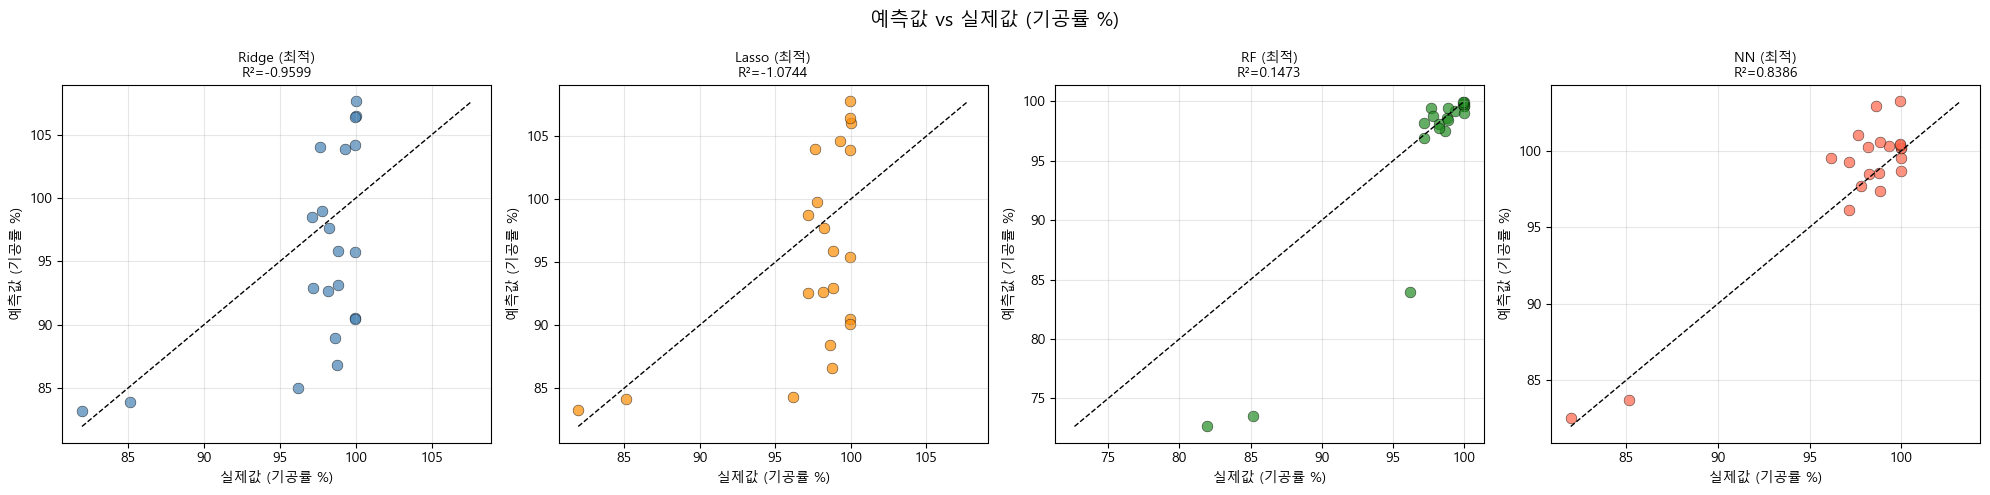

result_rf_nn_ridge_lasso_porosity.png 저장 완료


In [8]:
# ── 예측값 vs 실제값 시각화 ──
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('예측값 vs 실제값 (기공률 %)', fontsize=14)

plot_data = {
    'Ridge (최적)': (ridge_te, 'steelblue'),
    'Lasso (최적)': (lasso_te, 'darkorange'),
    'RF (최적)':    (rf_te,    'forestgreen'),
    'NN (최적)':    (nn_te,    'tomato'),
}

for ax, (name, (y_pred, color)) in zip(axes, plot_data.items()):
    ax.scatter(y4_te, y_pred, alpha=0.7, color=color, edgecolors='k', linewidths=0.4, s=60)
    lo = min(y4_te.min(), y_pred.min())
    hi = max(y4_te.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1)
    r2 = r2_score(y4_te, y_pred)
    ax.set_title(f'{name}\nR²={r2:.4f}', fontsize=10)
    ax.set_xlabel('실제값 (기공률 %)')
    ax.set_ylabel('예측값 (기공률 %)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('result_rf_nn_ridge_lasso_porosity.png', dpi=150, bbox_inches='tight')
plt.show()
print('result_rf_nn_ridge_lasso_porosity.png 저장 완료')